In [2]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# --- Load Data from Previous Steps ---
A_basis = np.load('../data/A_basis.npy')
eigenvalues = np.load('../data/eigenvalues.npy')
eigenvectors = np.load('../data/eigenvectors.npy')
PC_scores = np.load('../data/PC_scores.npy')
variance_explained = np.load('../data/variance_explained.npy')
cumulative_variance = np.load('../data/cumulative_variance.npy')
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values
basis_features = pd.read_csv('../data/basis_features.csv').iloc[:, 0].values

print("Data loaded successfully!")
print(f"A_basis shape      : {A_basis.shape}")
print(f"Eigenvalues shape  : {eigenvalues.shape}")
print(f"Eigenvectors shape : {eigenvectors.shape}")
print(f"PC_scores shape    : {PC_scores.shape}")

Data loaded successfully!
A_basis shape      : (1130, 9)
Eigenvalues shape  : (9,)
Eigenvectors shape : (9, 9)
PC_scores shape    : (1130, 9)


In [4]:
# --- What is System Simplification? ---
# Diagonalization transforms a matrix into a simpler form:
#   A = P D P⁻¹
# where:
#   P = matrix of eigenvectors (columns)
#   D = diagonal matrix of eigenvalues
#   P⁻¹ = inverse of eigenvector matrix
#
# For symmetric matrices (like our covariance matrix):
#   A = P D Pᵀ  (since P⁻¹ = Pᵀ for orthogonal P)
#
# This lets us:
#   → Keep only top k eigenvectors (most important directions)
#   → Discard noise (small eigenvalues)
#   → Build a compressed, simplified player model

In [5]:
# --- Step 1: Diagonalization of Covariance Matrix ---
C = np.cov(A_basis.T)

# Build diagonal matrix D from eigenvalues
D = np.diag(eigenvalues)
P = eigenvectors  # columns are eigenvectors

print("=" * 50)
print("DIAGONALIZATION: C = P D Pᵀ")
print("=" * 50)
print(f"C shape : {C.shape}")
print(f"P shape : {P.shape}")
print(f"D shape : {D.shape}")
print(f"\nDiagonal Matrix D (eigenvalues on diagonal):")
print(np.round(D, 2))

DIAGONALIZATION: C = P D Pᵀ
C shape : (9, 9)
P shape : (9, 9)
D shape : (9, 9)

Diagonal Matrix D (eigenvalues on diagonal):
[[3.034149e+04 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 2.689680e+03 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 5.163500e+02 0.000000e+00 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 8.956000e+01 0.000000e+00
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 4.737000e+01
  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  1.236000e+01 0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00 7.530000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.0000

In [6]:
# --- Verify Diagonalization ---
# Reconstruct C from P, D, P^T and compare with original

C_reconstructed = P @ D @ P.T
max_error = np.max(np.abs(C - C_reconstructed))

print("=" * 50)
print("VERIFICATION: C = P D Pᵀ")
print("=" * 50)
print(f"Max reconstruction error : {max_error:.6e}")
if max_error < 1e-6:
    print("✅ Diagonalization verified — C = PDPᵀ is correct!")
else:
    print("⚠️  Small numerical error — acceptable for floating point")

print(f"\nOriginal C (first 3x3):")
print(np.round(C[:3, :3], 2))
print(f"\nReconstructed C (first 3x3):")
print(np.round(C_reconstructed[:3, :3], 2))

VERIFICATION: C = P D Pᵀ
Max reconstruction error : 1.455192e-11
✅ Diagonalization verified — C = PDPᵀ is correct!

Original C (first 3x3):
[[   30.55   553.88    37.58]
 [  553.88 29261.91  2193.94]
 [   37.58  2193.94   273.25]]

Reconstructed C (first 3x3):
[[   30.55   553.88    37.58]
 [  553.88 29261.91  2193.94]
 [   37.58  2193.94   273.25]]


In [7]:
# --- Step 2: Choose Number of Components to Keep ---
# We keep only the top k components that explain
# enough variance — this is system simplification!

# Find k for 80%, 90%, 95% variance thresholds
k_80 = int(np.argmax(cumulative_variance >= 80) + 1)
k_90 = int(np.argmax(cumulative_variance >= 90) + 1)
k_95 = int(np.argmax(cumulative_variance >= 95) + 1)
k_full = len(eigenvalues)

print("=" * 50)
print("CHOOSING NUMBER OF COMPONENTS")
print("=" * 50)
print(f"Total features (original) : {k_full}")
print(f"Components for 80% var    : {k_80}")
print(f"Components for 90% var    : {k_90}")
print(f"Components for 95% var    : {k_95}")
print(f"\nWe will use k = {k_90} components (90% variance)")

k = k_90  # chosen number of components

CHOOSING NUMBER OF COMPONENTS
Total features (original) : 9
Components for 80% var    : 1
Components for 90% var    : 1
Components for 95% var    : 2

We will use k = 1 components (90% variance)


In [8]:
# --- Step 3: Build Reduced System ---
# Keep only top k eigenvectors and eigenvalues
# This is the simplified, diagonalized model

P_k = eigenvectors[:, :k]      # top k eigenvectors (n_features x k)
D_k = np.diag(eigenvalues[:k]) # top k eigenvalues  (k x k)

print("=" * 50)
print(f"REDUCED SYSTEM (k={k} components)")
print("=" * 50)
print(f"Full eigenvector matrix P    : {eigenvectors.shape}")
print(f"Reduced eigenvector matrix Pk: {P_k.shape}")
print(f"Full diagonal matrix D       : {D.shape}")
print(f"Reduced diagonal matrix Dk   : {D_k.shape}")

# Project players into reduced space
A_reduced = A_basis @ P_k  # (n_players x k)
print(f"\nOriginal player matrix shape : {A_basis.shape}")
print(f"Reduced player matrix shape  : {A_reduced.shape}")
print(f"\nDimensionality reduced from {A_basis.shape[1]} → {k} ✅")

REDUCED SYSTEM (k=1 components)
Full eigenvector matrix P    : (9, 9)
Reduced eigenvector matrix Pk: (9, 1)
Full diagonal matrix D       : (9, 9)
Reduced diagonal matrix Dk   : (1, 1)

Original player matrix shape : (1130, 9)
Reduced player matrix shape  : (1130, 1)

Dimensionality reduced from 9 → 1 ✅


In [9]:
# --- Step 4: Reconstruct from Reduced System ---
# Can we get back the original data from reduced system?
# A_reconstructed = A_reduced @ P_k^T

A_reconstructed = A_reduced @ P_k.T

reconstruction_error = np.mean(
    np.linalg.norm(A_basis - A_reconstructed, axis=1)
)

print("=" * 50)
print("RECONSTRUCTION FROM REDUCED SYSTEM")
print("=" * 50)
print(f"Original shape      : {A_basis.shape}")
print(f"Reconstructed shape : {A_reconstructed.shape}")
print(f"Mean reconstruction error : {reconstruction_error:.4f}")
print(f"Variance retained         : {cumulative_variance[k-1]:.2f}%")
print(f"Information lost          : {100 - cumulative_variance[k-1]:.2f}%")

RECONSTRUCTION FROM REDUCED SYSTEM
Original shape      : (1130, 9)
Reconstructed shape : (1130, 9)
Mean reconstruction error : 48.1524
Variance retained         : 90.01%
Information lost          : 9.99%


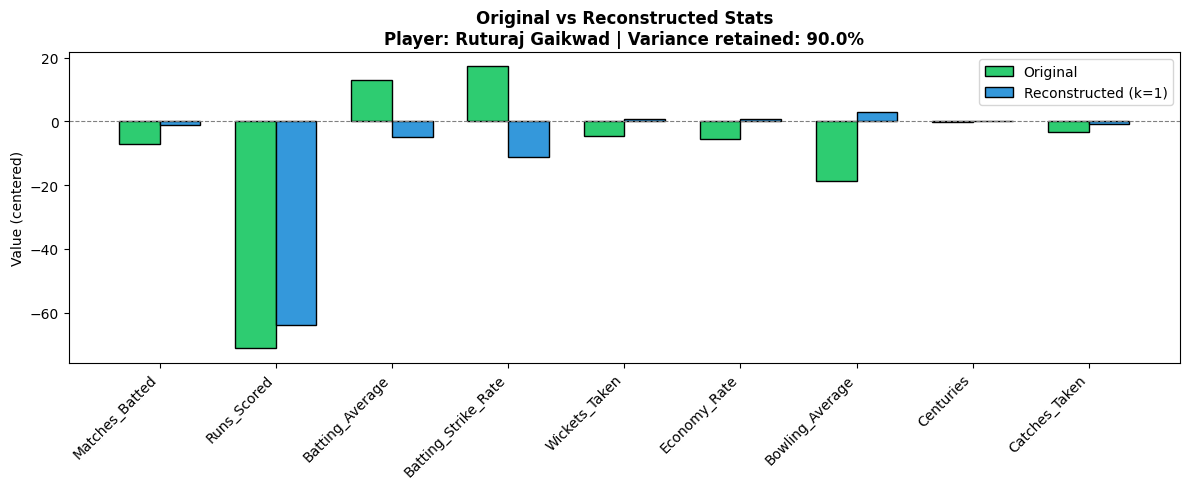

In [10]:
# --- Visualize: Original vs Reconstructed ---
# Show how well we recover a player's stats
# using only k components

test_idx = 0
test_name = player_names[test_idx]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(basis_features))
width = 0.35

ax.bar(x - width/2, A_basis[test_idx], width,
       label='Original', color='#2ecc71', edgecolor='black')
ax.bar(x + width/2, A_reconstructed[test_idx], width,
       label=f'Reconstructed (k={k})',
       color='#3498db', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(basis_features, rotation=45, ha='right')
ax.set_ylabel('Value (centered)')
ax.set_title(f'Original vs Reconstructed Stats\n'
             f'Player: {test_name} | '
             f'Variance retained: {cumulative_variance[k-1]:.1f}%',
             fontweight='bold', fontsize=12)
ax.legend()
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/step9_reconstruction.png', dpi=150)
plt.show()

In [11]:
# --- Step 5: Player Recommendation System ---
# The FINAL APPLICATION OUTPUT of EigenEleven!
# Use reduced PC scores to find similar players

def recommend_similar_players(player_name, top_n=5):
    """
    Given a player name, find the top_n most similar
    players using distance in reduced PC space.
    """
    # Find player index
    matches = [i for i, name in enumerate(player_names)
               if player_name.lower() in name.lower()]

    if not matches:
        print(f"Player '{player_name}' not found!")
        return

    idx = matches[0]
    player_vec = A_reduced[idx]

    # Compute distances in reduced space
    distances = np.array([
        np.linalg.norm(A_reduced[i] - player_vec)
        for i in range(len(player_names))
    ])
    distances[idx] = np.inf  # exclude self

    similar_idx = np.argsort(distances)[:top_n]

    print(f"\n{'='*50}")
    print(f"PLAYERS SIMILAR TO: {player_names[idx]}")
    print(f"(based on {k}-component reduced model)")
    print(f"{'='*50}")
    for rank, sim_idx in enumerate(similar_idx):
        print(f"  {rank+1}. {player_names[sim_idx]:<25} "
              f"distance: {distances[sim_idx]:.2f}")

    return similar_idx

# Test with a few players
recommend_similar_players("Virat Kohli")
recommend_similar_players("MS Dhoni")
recommend_similar_players("Rohit Sharma")


PLAYERS SIMILAR TO: Virat Kohli
(based on 1-component reduced model)
  1. Ravichandran Ashwin       distance: 0.25
  2. Piyush Chawla             distance: 0.27
  3. Washington Sundar         distance: 0.68
  4. Suryakumar Yadav          distance: 0.73
  5. Sam Curran                distance: 1.01

PLAYERS SIMILAR TO: MS Dhoni
(based on 1-component reduced model)
  1. Anuj Rawat                distance: 0.01
  2. Sameer Rizvi              distance: 0.02
  3. Shreyas Iyer              distance: 0.03
  4. Devdutt Padikkal          distance: 0.04
  5. Ishan Kishan              distance: 0.04

PLAYERS SIMILAR TO: Rohit Sharma
(based on 1-component reduced model)
  1. Riyan Parag               distance: 0.01
  2. Andre Russell             distance: 1.02
  3. Shahbaz Ahamad            distance: 1.17
  4. Harpreet Brar             distance: 1.50
  5. Ramandeep Singh           distance: 1.55


array([ 806,  410, 1080,  732,  397])

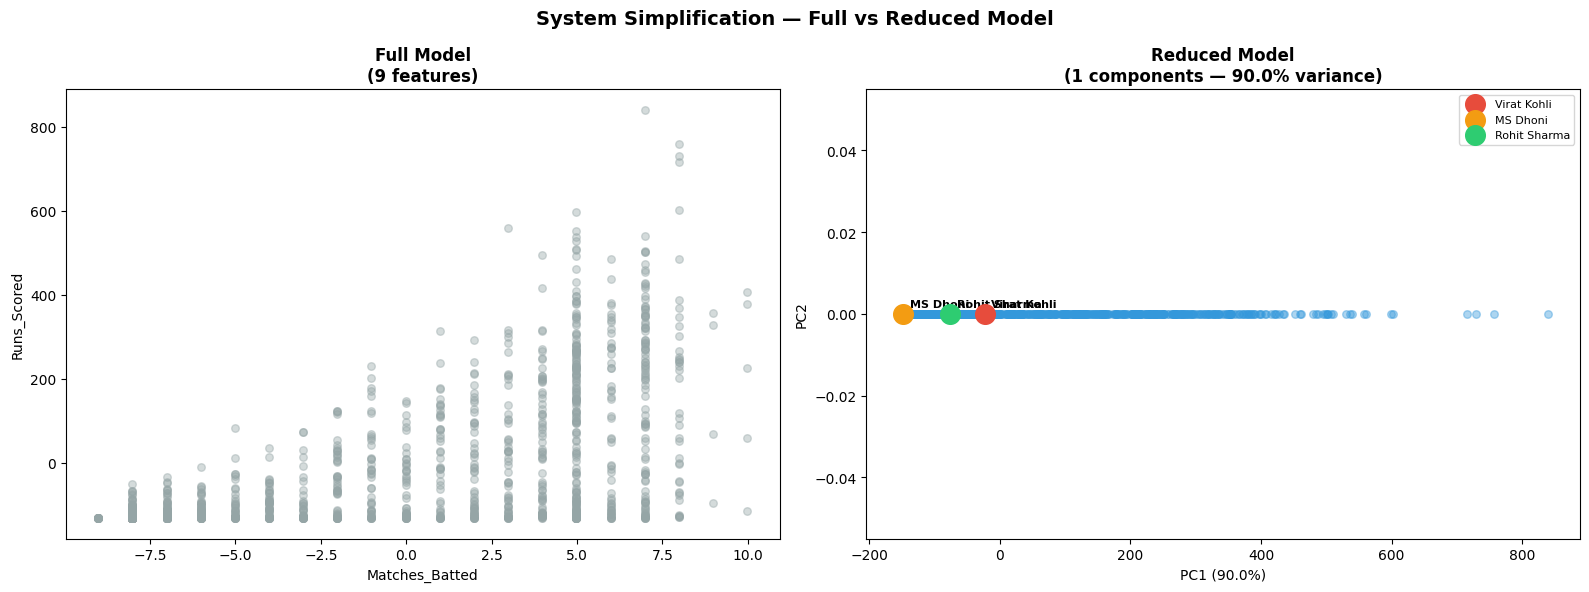

In [12]:
# --- Visualize Reduced Model — Player Clusters ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full model (all features)
axes[0].scatter(A_basis[:, 0], A_basis[:, 1],
                alpha=0.4, color='#95a5a6', s=30)
axes[0].set_xlabel(basis_features[0])
axes[0].set_ylabel(basis_features[1])
axes[0].set_title(f'Full Model\n({A_basis.shape[1]} features)',
                  fontweight='bold')

# Plot 2: Reduced model (k components)
scatter = axes[1].scatter(A_reduced[:, 0],
                          A_reduced[:, 1] if k > 1 else
                          np.zeros(len(A_reduced)),
                          alpha=0.4, color='#3498db', s=30)

# Highlight top players
top_players = ['Virat Kohli', 'MS Dhoni', 'Rohit Sharma']
colors_highlight = ['#e74c3c', '#f39c12', '#2ecc71']

for player, color in zip(top_players, colors_highlight):
    matches = [i for i, name in enumerate(player_names)
               if player.lower() in name.lower()]
    if matches:
        idx = matches[0]
        axes[1].scatter(A_reduced[idx, 0],
                        A_reduced[idx, 1] if k > 1 else 0,
                        color=color, s=200, zorder=5,
                        label=player_names[idx])
        axes[1].annotate(player_names[idx],
                         (A_reduced[idx, 0],
                          A_reduced[idx, 1] if k > 1 else 0),
                         fontsize=8, fontweight='bold',
                         xytext=(5, 5),
                         textcoords='offset points')

axes[1].set_xlabel(f'PC1 ({variance_explained[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variance_explained[1]:.1f}%)' if k > 1
                   else 'PC2')
axes[1].set_title(f'Reduced Model\n({k} components — '
                  f'{cumulative_variance[k-1]:.1f}% variance)',
                  fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('System Simplification — Full vs Reduced Model',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step9_full_vs_reduced.png', dpi=150)
plt.show()

In [13]:
# --- Final Summary of Entire Pipeline ---
print("=" * 55)
print("EIGENNELEVEN — COMPLETE PIPELINE SUMMARY")
print("=" * 55)
print(f"""
DATASET
  Players  : {A_basis.shape[0]}
  Features : {len(basis_features)} → {list(basis_features)}

STEP 1 — Matrix Representation
  Built {A_basis.shape[0]} x {len(basis_features)} player-stats matrix A

STEP 2 — Matrix Simplification
  RREF computed | Rank = {len(basis_features)} | LU Decomposition verified

STEP 3 — Structure of the Space
  Column Space, Row Space, Null Space analyzed
  Rank-Nullity Theorem verified ✓

STEP 4 — Remove Redundancy
  Correlation-based basis selection
  Reduced to {len(basis_features)} independent features

STEP 5 — Orthogonalization
  Gram-Schmidt applied | Q^T Q = I verified ✓

STEP 6 — Projection
  P = QQᵀ | Missing stat recovery demonstrated

STEP 7 — Least Squares
  np.linalg.lstsq | Normal Equations verified
  R² = {np.load('../data/weights.npy').shape[0]} weights learned

STEP 8 — Pattern Discovery
  λ1 = {eigenvalues[0]:.2f} explains {variance_explained[0]:.1f}% variance
  3 playing styles discovered: Batting, Bowling, All-Rounder

STEP 9 — System Simplification
  Diagonalization: C = PDPᵀ verified ✓
  {len(basis_features)} features → {k} components ({cumulative_variance[k-1]:.1f}% variance retained)
  Player recommendation system built ✅

FINAL OUTPUT
  → Predict missing player stats (Projection + Least Squares)
  → Discover playing styles (Eigenvalues + PCA)
  → Recommend similar players (Reduced model distance)
""")

# Save final reduced matrix
np.save('../data/A_reduced.npy', A_reduced)
np.save('../data/P_k.npy', P_k)

print("✅ Step 9 Complete!")
print("✅ EigenEleven Pipeline Complete!")

EIGENNELEVEN — COMPLETE PIPELINE SUMMARY

DATASET
  Players  : 1130
  Features : 9 → ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Catches_Taken']

STEP 1 — Matrix Representation
  Built 1130 x 9 player-stats matrix A

STEP 2 — Matrix Simplification
  RREF computed | Rank = 9 | LU Decomposition verified

STEP 3 — Structure of the Space
  Column Space, Row Space, Null Space analyzed
  Rank-Nullity Theorem verified ✓

STEP 4 — Remove Redundancy
  Correlation-based basis selection
  Reduced to 9 independent features

STEP 5 — Orthogonalization
  Gram-Schmidt applied | Q^T Q = I verified ✓

STEP 6 — Projection
  P = QQᵀ | Missing stat recovery demonstrated

STEP 7 — Least Squares
  np.linalg.lstsq | Normal Equations verified
  R² = 9 weights learned

STEP 8 — Pattern Discovery
  λ1 = 30341.49 explains 90.0% variance
  3 playing styles discovered: Batting, Bowling, All-Rounder

STEP 9 — System Si